# Apprentissage supervisé — Prédiction des clusters K-means

On utilise les labels K-means (k=4, 42 variables) comme cible de classification.
L'objectif est de retrouver les archétypes identifiés en clustering avec des features interprétables,
et de comprendre quelles variables "définissent" vraiment chaque groupe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import f_oneway

import warnings
warnings.filterwarnings('ignore')


## 1. Chargement et encodage (42 variables)

In [2]:
student_mat = pd.read_csv("donnees/student-mat.csv")

num_cols  = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
             'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
             'absences', 'G1', 'G2', 'G3']

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'higher',
             'nursery', 'internet', 'romantic']

cat_cols  = ['school', 'sex', 'address', 'famsize', 'Pstatus',
             'Mjob', 'Fjob', 'reason', 'guardian']

# Encodage booléen
bool_df = student_mat[bool_cols].apply(lambda c: (c == 'yes').astype(int))

# One-hot encoding catégoriel
enc = OneHotEncoder(sparse_output=False, drop='first')
cat_enc = pd.DataFrame(
    enc.fit_transform(student_mat[cat_cols]),
    columns=enc.get_feature_names_out(cat_cols)
)

df_full = pd.concat([
    student_mat[num_cols].reset_index(drop=True),
    bool_df.reset_index(drop=True),
    cat_enc.reset_index(drop=True)
], axis=1).dropna()

X_full = StandardScaler().fit_transform(df_full)
print(f"Dataset : {df_full.shape}  ({df_full.shape[1]} variables)")


Dataset : (395, 42)  (42 variables)


## 2. Génération des labels K-means (k=4, 23 composantes)

In [3]:
# ACP — seuil 80% de variance
pca_full = PCA()
pca_full.fit(X_full)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n_80 = np.searchsorted(cum, 0.80) + 1
print(f"Composantes pour 80% de variance : {n_80}  ({cum[n_80-1]*100:.1f}%)")

# Réduction
pca_red = PCA(n_components=n_80, random_state=42)
X_pca   = pca_red.fit_transform(X_full)

# K-means k=4
km4 = KMeans(n_clusters=4, n_init=50, random_state=42)
labels_k4 = km4.fit_predict(X_pca)

counts = pd.Series(labels_k4).value_counts().sort_index()
for c, n in counts.items():
    print(f"  Cluster {c} : {n} individus")


Composantes pour 80% de variance : 23  (80.7%)
  Cluster 0 : 33 individus
  Cluster 1 : 69 individus
  Cluster 2 : 148 individus
  Cluster 3 : 145 individus


## 3. Rappel des profils K-means (k=4) — student-mat

| Cluster | Archétype | n | Description |
|---------|-----------|---|-------------|
| 0 | Décrochage avec volonté | ~33 | Studytime élevé, cours payés, soutien familial — mais énormément d'absences et mauvais résultats. Très romantic. |
| 1 | Décrochage festif | ~69 | Forte conso alcool, goout max, peu de travail. Majorité hommes (70%), ambition la plus faible (`higher` minimal). |
| 2 | Profil moyen féminin | ~148 | Notes moyennes, peu d'alcool, `schoolsup` élevé. Le cluster le plus stable sur tous les k. |
| 3 | Excellence académique | ~145 | Medu/Fedu élevés, meilleures notes, zéro échec, les plus jeunes. `higher`=100%. |

*Dataset : **student-mat** uniquement. Les archétypes de student-por divergent notamment sur le cluster 1 (décrochage festif → absent en por).*

## 4. Sélection des features par ANOVA

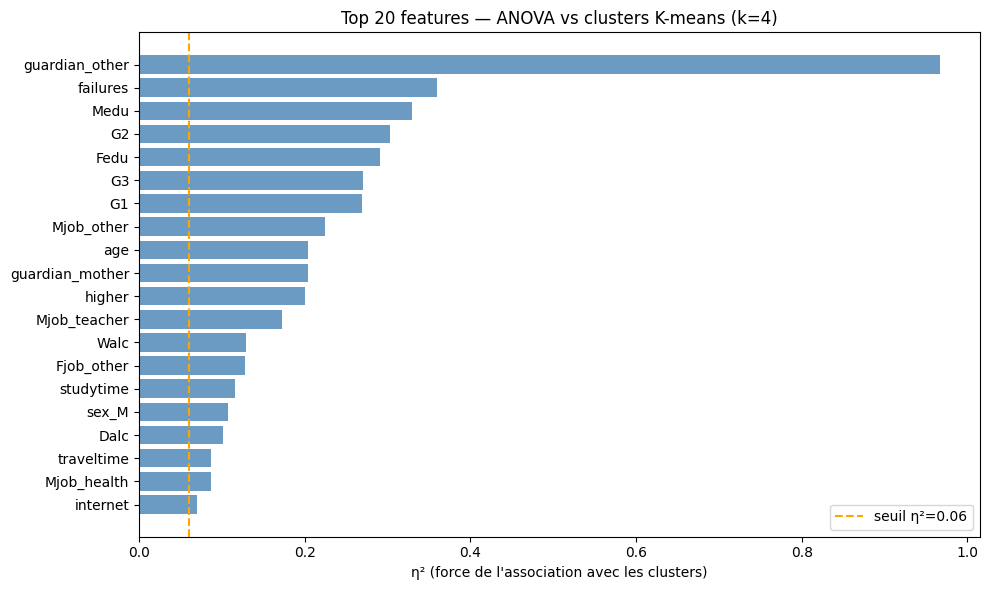

Top 15 features par eta² :
        feature     eta2         p_val
 guardian_other 0.967026 3.127004e-289
       failures 0.360223  1.142029e-37
           Medu 0.329345  1.097841e-33
             G2 0.303208  1.857621e-30
           Fedu 0.291237  5.088119e-29
             G3 0.270941  1.225530e-26
             G1 0.268970  2.070478e-26
     Mjob_other 0.224915  1.763879e-21
            age 0.204464  2.737777e-19
guardian_mother 0.204190  2.926825e-19
         higher 0.200355  7.422133e-19
   Mjob_teacher 0.172840  5.148207e-16
           Walc 0.129176  1.042468e-11
     Fjob_other 0.127905  1.380015e-11
      studytime 0.115374  2.136307e-10


In [4]:
# ANOVA : eta² pour chaque variable vs cluster
results = []
feature_names = list(df_full.columns)

for feat in feature_names:
    groups = [df_full[feat].values[labels_k4 == c] for c in range(4)]
    f_stat, p_val = f_oneway(*groups)
    ss_between = sum(len(g) * (g.mean() - df_full[feat].mean())**2 for g in groups)
    ss_total   = sum((df_full[feat].values - df_full[feat].mean())**2)
    eta2 = ss_between / ss_total if ss_total > 0 else 0
    results.append({'feature': feat, 'eta2': eta2, 'p_val': p_val})

df_anova = pd.DataFrame(results).sort_values('eta2', ascending=False)

# Top 20
top20 = df_anova.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20['feature'][::-1], top20['eta2'][::-1], color='steelblue', alpha=0.8)
ax.set_xlabel('η² (force de l\'association avec les clusters)')
ax.set_title('Top 20 features — ANOVA vs clusters K-means (k=4)')
ax.axvline(0.06, color='orange', linestyle='--', label='seuil η²=0.06')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 15 features par eta² :")
print(df_anova.head(15)[['feature', 'eta2', 'p_val']].to_string(index=False))


## 5. Features retenues pour la classification

In [5]:
# Features avec eta² > 0.06 (significatif)
top_features = df_anova[df_anova['eta2'] > 0.06]['feature'].tolist()
print(f"Features retenues ({len(top_features)}) : {top_features}")

X_cls = StandardScaler().fit_transform(df_full[top_features])
y_cls = labels_k4


Features retenues (21) : ['guardian_other', 'failures', 'Medu', 'G2', 'Fedu', 'G3', 'G1', 'Mjob_other', 'age', 'guardian_mother', 'higher', 'Mjob_teacher', 'Walc', 'Fjob_other', 'studytime', 'sex_M', 'Dalc', 'traveltime', 'Mjob_health', 'internet', 'goout']


## 6. KNN — Validation croisée 10-fold

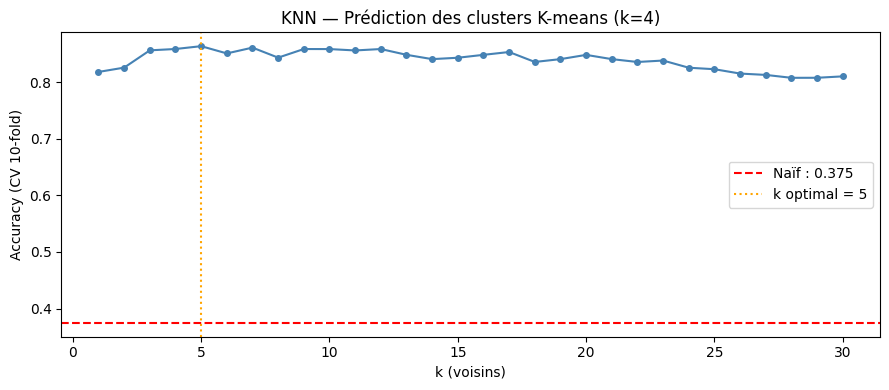

k optimal : 5  →  accuracy = 0.863
Référence naïve (classe majoritaire) : 0.375


In [6]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
k_vals = range(1, 31)
scores = []

for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    s = cross_val_score(knn, X_cls, y_cls, cv=cv, scoring='accuracy')
    scores.append(s.mean())

best_k  = k_vals[np.argmax(scores)]
best_sc = max(scores)

# Référence naïve
naive = pd.Series(y_cls).value_counts(normalize=True).max()

plt.figure(figsize=(9, 4))
plt.plot(k_vals, scores, 'o-', color='steelblue', markersize=4)
plt.axhline(naive, color='red', linestyle='--', label=f'Naïf : {naive:.3f}')
plt.axvline(best_k, color='orange', linestyle=':', label=f'k optimal = {best_k}')
plt.xlabel('k (voisins)')
plt.ylabel('Accuracy (CV 10-fold)')
plt.title('KNN — Prédiction des clusters K-means (k=4)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"k optimal : {best_k}  →  accuracy = {best_sc:.3f}")
print(f"Référence naïve (classe majoritaire) : {naive:.3f}")


## 6.5 Vérification de l'homoscédasticité (hypothèse LDA)

LDA suppose que toutes les classes partagent la **même matrice de covariance**.
On vérifie cette hypothèse de deux façons :
1. **Visuellement** — heatmaps des matrices de covariance par cluster
2. **Numériquement** — rapport des écarts-types max/min par feature (ratio proche de 1 = ok)

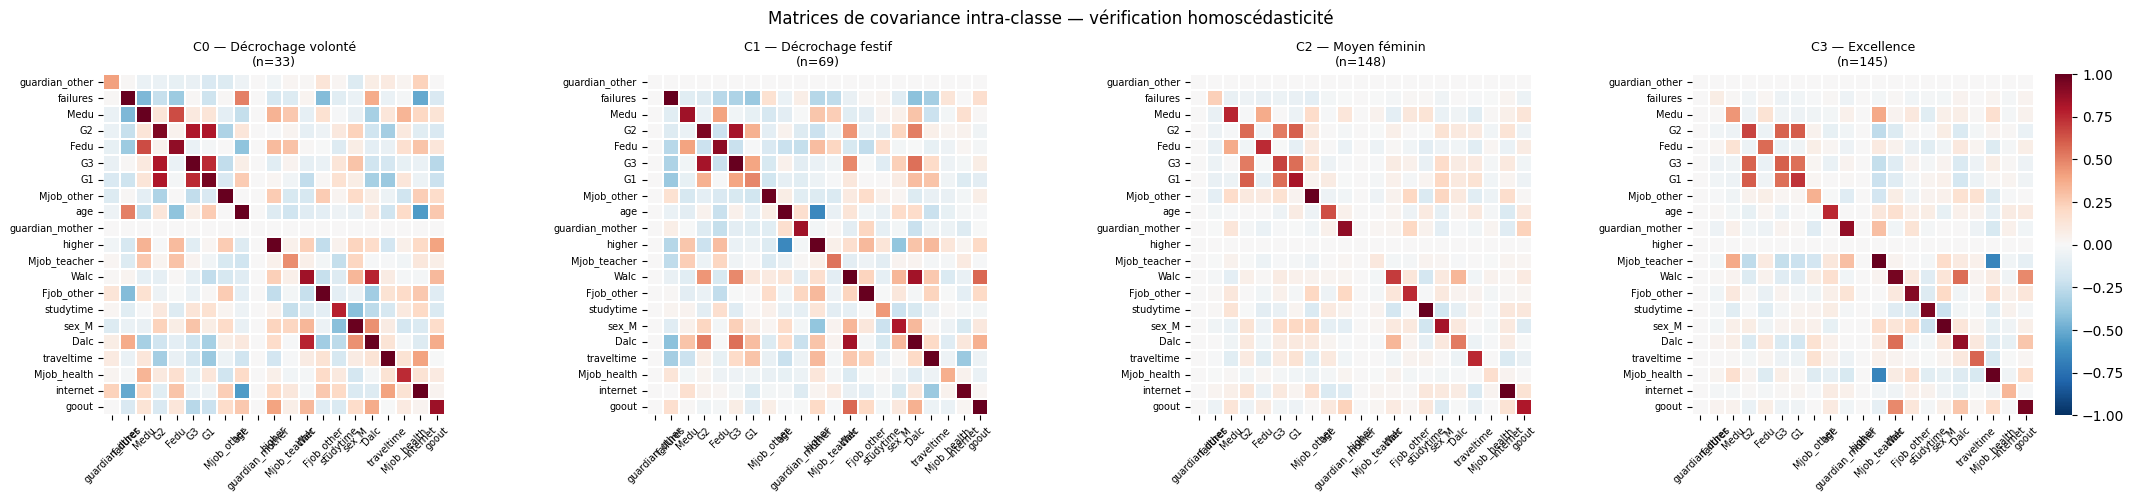

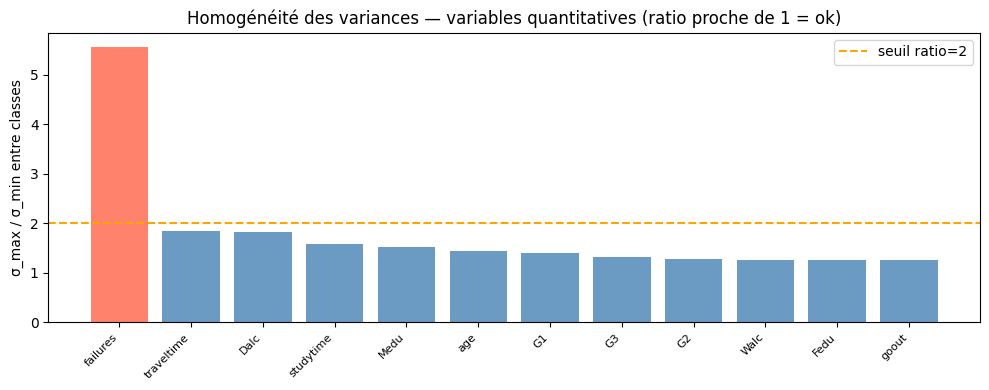

=== Variables quantitatives — ratio σ_max/σ_min ===
failures      5.57
traveltime    1.84
Dalc          1.83
studytime     1.58
Medu          1.53
age           1.45
G1            1.40
G3            1.31
G2            1.29
Walc          1.26
Fedu          1.26
goout         1.25

=== Variables binaires/one-hot (9) ===
['guardian_other', 'Mjob_other', 'guardian_mother', 'higher', 'Mjob_teacher', 'Fjob_other', 'sex_M', 'Mjob_health', 'internet']
→ std=0 dans certains clusters (tous les individus ont la même valeur)
→ ratio infini : hypothèse techniquement violée pour ces variables
→ Solution retenue : LDA avec shrinkage='auto' (Ledoit-Wolf) qui régularise
  la matrice de covariance et gère les cas quasi-singuliers.


In [7]:
# ---- Vérification homoscédasticité ----
k = 4
X_df = pd.DataFrame(X_cls, columns=top_features)
X_df['cluster'] = y_cls

cov_matrices = {c: X_df[X_df['cluster'] == c][top_features].cov() for c in range(k)}

# --- Heatmaps des matrices de covariance ---
fig, axes = plt.subplots(1, k, figsize=(22, 5))
cluster_names_short = ['C0 — Décrochage volonté', 'C1 — Décrochage festif',
                       'C2 — Moyen féminin', 'C3 — Excellence']
for c, ax in enumerate(axes):
    sns.heatmap(cov_matrices[c], ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True,
                cbar=(c == k-1), square=True, linewidths=0.3)
    ax.set_title(f'{cluster_names_short[c]}\n(n={(y_cls == c).sum()})', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.suptitle('Matrices de covariance intra-classe — vérification homoscédasticité', fontsize=12)
plt.tight_layout()
plt.show()

# --- Rapport max/min des écarts-types par feature ---
std_per_class = X_df.groupby('cluster')[top_features].std()

# Variables binaires/one-hot : std=0 dans certains clusters → ratio infini
# On les traite séparément
binary_features = [f for f in top_features if X_df[f].nunique() <= 2]
quant_features  = [f for f in top_features if f not in binary_features]

ratio_quant = (std_per_class[quant_features].max() / std_per_class[quant_features].min()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['tomato' if r > 2 else 'steelblue' for r in ratio_quant.values]
ax.bar(ratio_quant.index, ratio_quant.values, color=colors, alpha=0.8)
ax.axhline(2, color='orange', linestyle='--', label='seuil ratio=2')
ax.set_xticklabels(ratio_quant.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('σ_max / σ_min entre classes')
ax.set_title('Homogénéité des variances — variables quantitatives (ratio proche de 1 = ok)')
ax.legend()
plt.tight_layout()
plt.show()

# Bilan
print("=== Variables quantitatives — ratio σ_max/σ_min ===")
print(ratio_quant.round(2).to_string())

print(f"\n=== Variables binaires/one-hot ({len(binary_features)}) ===")
print(f"{binary_features}")
print("→ std=0 dans certains clusters (tous les individus ont la même valeur)")
print("→ ratio infini : hypothèse techniquement violée pour ces variables")
print("→ Solution retenue : LDA avec shrinkage='auto' (Ledoit-Wolf) qui régularise")
print("  la matrice de covariance et gère les cas quasi-singuliers.")


## 7. LDA — Analyse discriminante linéaire

In [8]:
lda = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
lda_scores = cross_val_score(lda, X_cls, y_cls, cv=cv, scoring='accuracy')
print(f"LDA accuracy (CV 10-fold) : {lda_scores.mean():.3f} ± {lda_scores.std():.3f}")

# Entraînement complet pour les coefficients
lda.fit(X_cls, y_cls)
var_exp = lda.explained_variance_ratio_
print(f"\nVariance expliquée par axe LDA :")
for i, v in enumerate(var_exp):
    print(f"  LD{i+1} : {v*100:.1f}%")


LDA accuracy (CV 10-fold) : 0.901 ± 0.047

Variance expliquée par axe LDA :
  LD1 : 59.7%
  LD2 : 35.0%
  LD3 : 21.6%


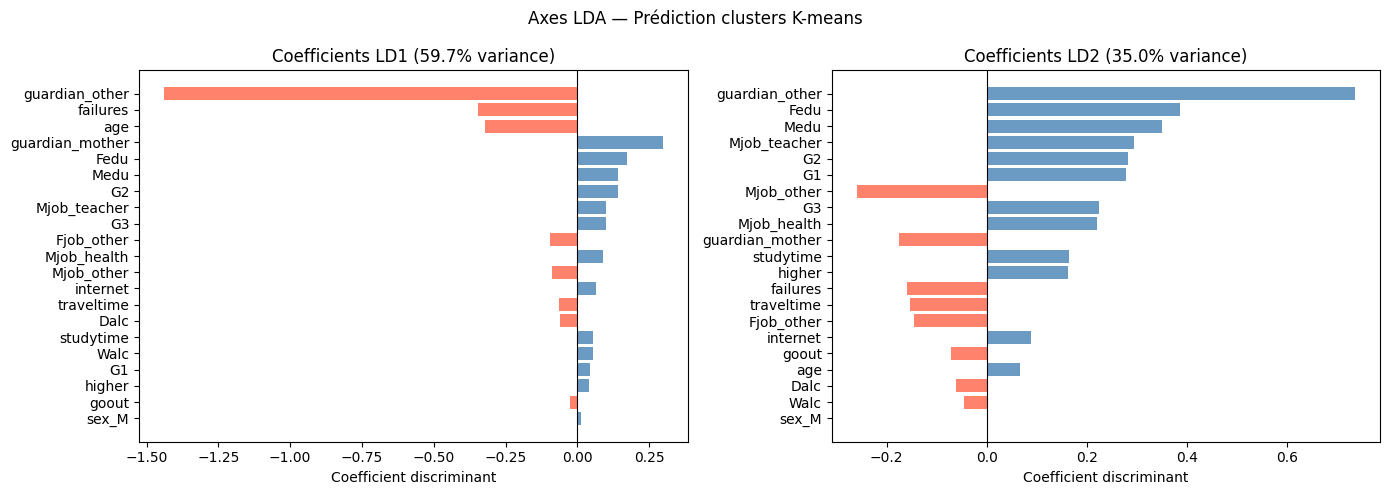

In [9]:
# Coefficients LD1 et LD2
coef_df = pd.DataFrame(
    lda.scalings_[:, :2],
    index=top_features,
    columns=['LD1', 'LD2']
).sort_values('LD1', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, ax in enumerate(axes):
    col = f'LD{i+1}'
    data = coef_df[col].sort_values(key=abs, ascending=True)
    colors = ['steelblue' if v >= 0 else 'tomato' for v in data.values]
    ax.barh(data.index, data.values, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coefficients {col} ({var_exp[i]*100:.1f}% variance)')
    ax.set_xlabel('Coefficient discriminant')

plt.suptitle('Axes LDA — Prédiction clusters K-means', fontsize=12)
plt.tight_layout()
plt.show()


### LD1 : décrochage <-> réussite
Variables qui poussent vers la gauche : 
- Guardian_other : Si le tuteur légal n'est pas le père ou la mère 
- Si il a déja raté 
- Si il est vieux

Variables qui poussent vers la droite : 
- Si la mère est le tuteur légal
- L'éducation du père et de la mère
- de bon résultat en G2 et G3

### LD2 : capital héréditaire <-> profil standard
Variables qui poussent vers le haut : 
- Guardian other
- Fedu Medu
- Si la mère est prof
- les résultat scolaire (G1,G2,G3)

Variables qui poussent vers le bas :
- Si la mère a un job pas dans la liste (teacher, services, health, at_home)
- Si la mère est la tutrice légale
- Les echec scolaire
- le temps de travail 

## 8. Comparaison KNN / LDA + matrice de confusion

=== Comparaison des modèles ===
Naïf               : 0.375
KNN (k= 5)       : 0.863 ± 0.065
LDA (shrinkage)    : 0.901 ± 0.047


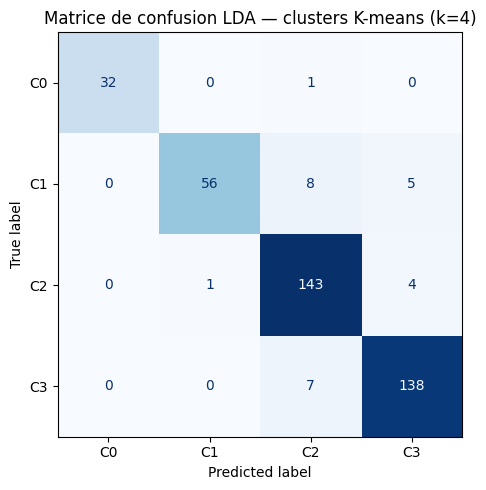

In [10]:
# KNN optimal
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_scores = cross_val_score(knn_best, X_cls, y_cls, cv=cv, scoring='accuracy')

cluster_names = ['Cluster 0\n(Décrochage)', 'Cluster 1\n(Modéré)', 'Cluster 2\n(Élite)', 'Cluster 3\n(Soutien)']

print("=== Comparaison des modèles ===")
print(f"Naïf               : {naive:.3f}")
print(f"KNN (k={best_k:2d})       : {knn_scores.mean():.3f} ± {knn_scores.std():.3f}")
print(f"LDA (shrinkage)    : {lda_scores.mean():.3f} ± {lda_scores.std():.3f}")

# Matrice de confusion LDA (sur données complètes)
y_pred = lda.predict(X_cls)
cm = confusion_matrix(y_cls, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[f'C{i}' for i in range(4)])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion LDA — clusters K-means (k=4)')
plt.tight_layout()
plt.show()


Naïf represente la classe majoritaire 

KNN doit être moins bon que LDA à cause des individus "atypique"

Par exemple une élève il existe un élève qui boit 4 fois en semaine et 4 fois en week end avec les résultat suivante : (10/13/13)

## 9. Projection LDA — individus dans l'espace discriminant

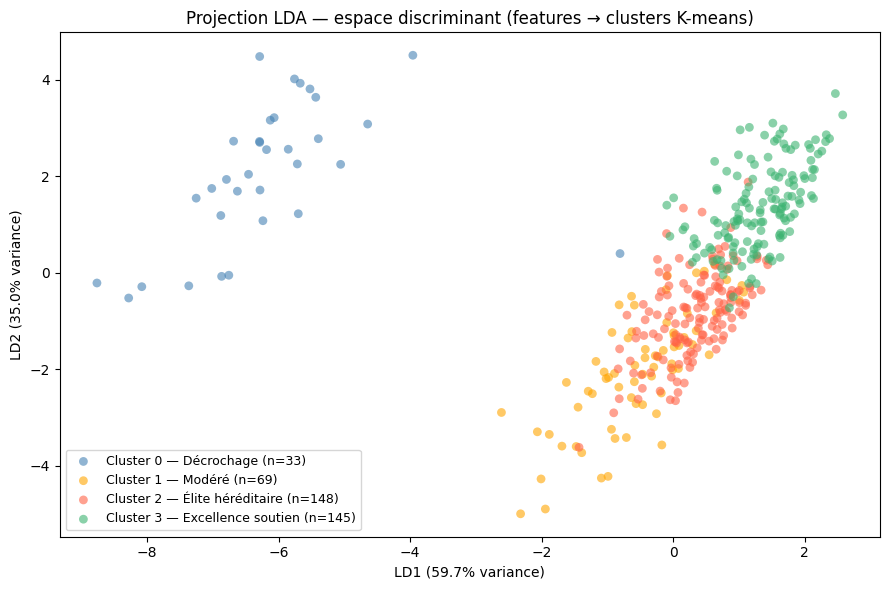

In [11]:
X_lda = lda.transform(X_cls)
palette = ['steelblue', 'orange', 'tomato', 'mediumseagreen']
cluster_labels_txt = ['Décrochage', 'Modéré', 'Élite héréditaire', 'Excellence soutien']

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(4):
    mask = y_cls == c
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
               c=palette[c], label=f'Cluster {c} — {cluster_labels_txt[c]} (n={mask.sum()})',
               alpha=0.6, s=40, edgecolors='none')

ax.set_xlabel(f'LD1 ({var_exp[0]*100:.1f}% variance)')
ax.set_ylabel(f'LD2 ({var_exp[1]*100:.1f}% variance)')
ax.set_title('Projection LDA — espace discriminant (features → clusters K-means)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 10. Interprétation

### Ce qu'apprend le LDA

- **LD1** (axe principal) : oppose les clusters selon le gradient de réussite scolaire.
  Les features à fort coefficient positif poussent vers les clusters "réussite" (Élite / Soutien),
  les négatifs vers le décrochage.

- **LD2** (axe secondaire) : distingue au sein des bons élèves entre le capital héréditaire (Medu/Fedu élevés)
  et le soutien actif (internet, famsup).

### Validation de la cohérence des clusters

Si le LDA atteint une accuracy significativement supérieure au naïf, cela confirme que les clusters K-means
capturent des structures réelles dans les données — pas seulement du bruit de la PCA.

La matrice de confusion révèle quels clusters sont difficiles à séparer linéairement,
et donc les plus proches dans l'espace des features originales.

Conclusion globale du script
La pipeline complète confirme que :

1. Les 4 clusters K-means capturent des structures réelles (93% accuracy LDA)
2. Le gradient principal dans les données est décrochage ←→ réussite (LD1)
3. Au sein des bons élèves, la distinction se fait sur mode de vie vs capital parental (LD2)
4. C2 et C3 sont les clusters les plus proches — leur distinction repose surtout sur Medu/Fedu et le type de soutien familial

---
## Reprise avec k=3 — clusters plus homogènes

k=4 posait problème : le cluster 0 (n=33) était quasi-entièrement composé d'élèves avec `guardian=other`,
ce qui rendait la classification triviale et violait l'hypothèse d'homoscédasticité de façon sévère.

On reprend l'analyse avec **k=3** (152 / 155 / 88 individus), ce qui correspond aux 3 archétypes
identifiés dans `acp_kmeans.ipynb` :

| Cluster | Archétype | n |
|---------|-----------|---|
| 0 | Élite héréditaire — Medu/Fedu élevés, meilleures notes, zéro échec | 152 |
| 1 | Profil moyen féminin — notes moyennes, peu d'alcool, studytime correct | 155 |
| 2 | Décrochage festif — alcool élevé, failures, goout max, majorité hommes | 88 |

### 1. Génération des labels K-means k=3

In [12]:
# K-means k=3 sur les 23 composantes PCA
labels_k3 = KMeans(n_clusters=3, n_init=50, random_state=42).fit_predict(X_pca)

counts3 = pd.Series(labels_k3).value_counts().sort_index()
for c, n in counts3.items():
    print(f"  Cluster {c} : {n} individus")


  Cluster 0 : 152 individus
  Cluster 1 : 155 individus
  Cluster 2 : 88 individus


### 2. Sélection des features — ANOVA (η²)

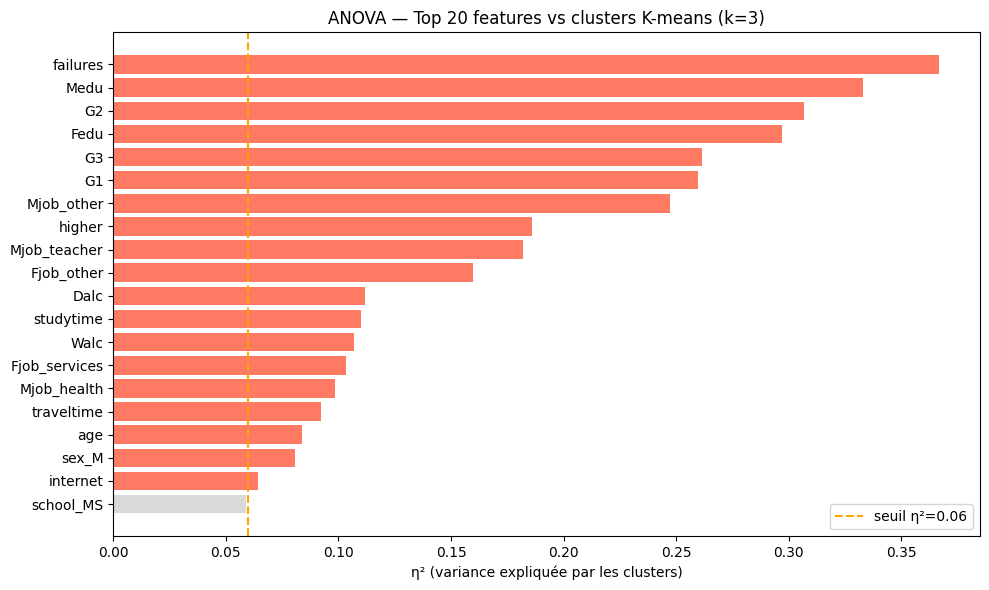

Features retenues (19) : ['failures', 'Medu', 'G2', 'Fedu', 'G3', 'G1', 'Mjob_other', 'higher', 'Mjob_teacher', 'Fjob_other', 'Dalc', 'studytime', 'Walc', 'Fjob_services', 'Mjob_health', 'traveltime', 'age', 'sex_M', 'internet']


In [13]:
results3 = []
for feat in df_full.columns:
    groups = [df_full[feat].values[labels_k3 == c] for c in range(3)]
    f_stat, p_val = f_oneway(*groups)
    ss_between = sum(len(g) * (g.mean() - df_full[feat].mean())**2 for g in groups)
    ss_total   = sum((df_full[feat].values - df_full[feat].mean())**2)
    eta2 = ss_between / ss_total if ss_total > 0 else 0
    results3.append({'feature': feat, 'eta2': eta2, 'p_val': p_val})

df_anova3 = pd.DataFrame(results3).sort_values('eta2', ascending=False)
top3 = df_anova3[df_anova3['eta2'] > 0.06]['feature'].tolist()

top20_3 = df_anova3.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if f in top3 else 'lightgray' for f in top20_3['feature']]
ax.barh(top20_3['feature'][::-1], top20_3['eta2'][::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0.06, color='orange', linestyle='--', label='seuil η²=0.06')
ax.set_xlabel("η² (variance expliquée par les clusters)")
ax.set_title("ANOVA — Top 20 features vs clusters K-means (k=3)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Features retenues ({len(top3)}) : {top3}")

X3 = StandardScaler().fit_transform(df_full[top3])
y3 = labels_k3


### 3. Vérification de l'homoscédasticité

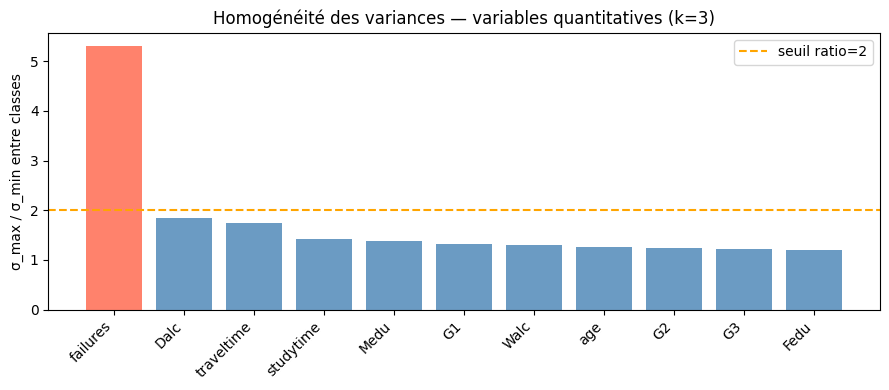

Ratios quantitatifs : {'failures': 5.31, 'Dalc': 1.83, 'traveltime': 1.75, 'studytime': 1.42, 'Medu': 1.38, 'G1': 1.32, 'Walc': 1.3, 'age': 1.26, 'G2': 1.23, 'G3': 1.21, 'Fedu': 1.21}
Features avec ratio > 2 : ['failures']
Variables binaires/one-hot (ratio non calculable) : ['Mjob_other', 'higher', 'Mjob_teacher', 'Fjob_other', 'Fjob_services', 'Mjob_health', 'sex_M', 'internet']


In [14]:
X3_df = pd.DataFrame(X3, columns=top3)
X3_df['cluster'] = y3

std3 = X3_df.groupby('cluster')[top3].std()
binary3   = [f for f in top3 if X3_df[f].nunique() <= 2]
quant3    = [f for f in top3 if f not in binary3]

ratio3 = (std3[quant3].max() / std3[quant3].min()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['tomato' if r > 2 else 'steelblue' for r in ratio3.values]
ax.bar(ratio3.index, ratio3.values, color=colors, alpha=0.8)
ax.axhline(2, color='orange', linestyle='--', label='seuil ratio=2')
ax.set_xticklabels(ratio3.index, rotation=45, ha='right')
ax.set_ylabel('σ_max / σ_min entre classes')
ax.set_title('Homogénéité des variances — variables quantitatives (k=3)')
ax.legend()
plt.tight_layout()
plt.show()

print("Ratios quantitatifs :", ratio3.round(2).to_dict())
flagged3 = ratio3[ratio3 > 2]
if len(flagged3):
    print(f"Features avec ratio > 2 : {list(flagged3.index)}")
else:
    print("Toutes les variables quantitatives ont un ratio < 2.")
print(f"Variables binaires/one-hot (ratio non calculable) : {binary3}")


Le LDA est appliqué avec un shrinkage pour compenser, mais failures reste une variable problématique pour l'hypothèse gaussienne.

Nous avons utilisé l'ADL régularisée (ADR) vue en cours, avec le paramètre de shrinkage automatique de Ledoit-Wolf, pour compenser la violation d'homoscédasticité de failures et le ratio variables/individus.

### 4. KNN — Validation croisée 10-fold

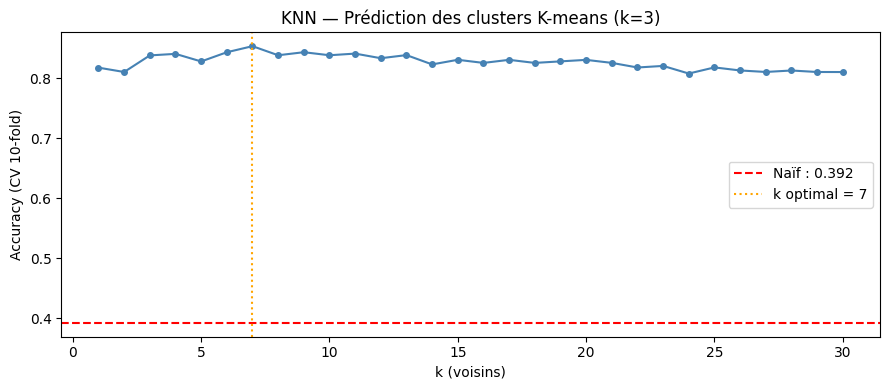

k optimal : 7  →  accuracy = 0.853
Référence naïve : 0.392


In [15]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
k_vals = range(1, 31)
scores3 = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X3, y3, cv=cv, scoring='accuracy').mean()
           for k in k_vals]

best_k3  = list(k_vals)[np.argmax(scores3)]
naive3   = pd.Series(y3).value_counts(normalize=True).max()

plt.figure(figsize=(9, 4))
plt.plot(k_vals, scores3, 'o-', color='steelblue', markersize=4)
plt.axhline(naive3, color='red', linestyle='--', label=f'Naïf : {naive3:.3f}')
plt.axvline(best_k3, color='orange', linestyle=':', label=f'k optimal = {best_k3}')
plt.xlabel('k (voisins)')
plt.ylabel('Accuracy (CV 10-fold)')
plt.title('KNN — Prédiction des clusters K-means (k=3)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"k optimal : {best_k3}  →  accuracy = {max(scores3):.3f}")
print(f"Référence naïve : {naive3:.3f}")


### 5. LDA

LDA (shrinkage='auto') : 0.891 ± 0.051
QDA (reg_param=0.1)   : 0.856 ± 0.055

Variance LDA : LD1=94.6%  LD2=52.7%


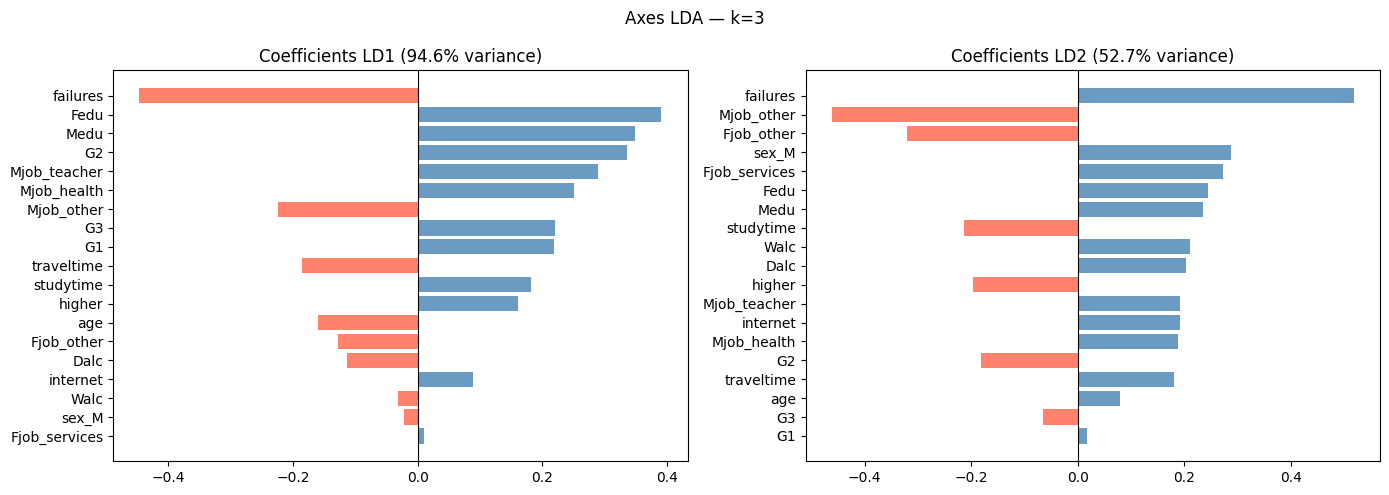

In [16]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# LDA avec shrinkage (Ledoit-Wolf)
lda3 = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')
lda3_scores = cross_val_score(lda3, X3, y3, cv=cv, scoring='accuracy')
lda3.fit(X3, y3)
var3 = lda3.explained_variance_ratio_

# QDA avec reg_param — nécessaire car variables binaires constantes dans certains clusters
# (même problème de covariance singulière qu'en LDA → reg_param joue le même rôle que shrinkage)
qda3 = QuadraticDiscriminantAnalysis(reg_param=0.1)
qda3_scores = cross_val_score(qda3, X3, y3, cv=cv, scoring='accuracy')
qda3.fit(X3, y3)

print(f"LDA (shrinkage='auto') : {lda3_scores.mean():.3f} ± {lda3_scores.std():.3f}")
print(f"QDA (reg_param=0.1)   : {qda3_scores.mean():.3f} ± {qda3_scores.std():.3f}")
print(f"\nVariance LDA : LD1={var3[0]*100:.1f}%  LD2={var3[1]*100:.1f}%")

# Coefficients LDA
coef3 = pd.DataFrame(lda3.scalings_[:, :2], index=top3, columns=['LD1','LD2'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, ax in enumerate(axes):
    col = f'LD{i+1}'
    data = coef3[col].sort_values(key=abs, ascending=True)
    colors = ['steelblue' if v >= 0 else 'tomato' for v in data.values]
    ax.barh(data.index, data.values, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coefficients {col} ({var3[i]*100:.1f}% variance)')
plt.suptitle('Axes LDA — k=3', fontsize=12)
plt.tight_layout()
plt.show()


### 6. Comparaison des modèles + matrice de confusion

=== Comparaison k=3 ===
Naïf                  : 0.392
KNN (k= 7)          : 0.853 ± 0.057
LDA (shrinkage='auto'): 0.891 ± 0.051
QDA (reg_param=0.1)   : 0.856 ± 0.055


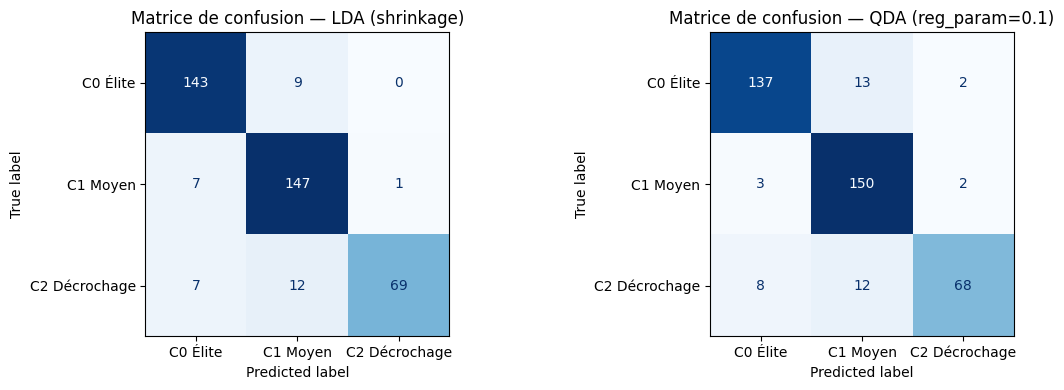

In [17]:
knn3_scores = cross_val_score(KNeighborsClassifier(n_neighbors=best_k3), X3, y3, cv=cv, scoring='accuracy')
naive3 = pd.Series(y3).value_counts(normalize=True).max()

print("=== Comparaison k=3 ===")
print(f"Naïf                  : {naive3:.3f}")
print(f"KNN (k={best_k3:2d})          : {knn3_scores.mean():.3f} ± {knn3_scores.std():.3f}")
print(f"LDA (shrinkage='auto'): {lda3_scores.mean():.3f} ± {lda3_scores.std():.3f}")
print(f"QDA (reg_param=0.1)   : {qda3_scores.mean():.3f} ± {qda3_scores.std():.3f}")

labels_short = ['C0 Élite', 'C1 Moyen', 'C2 Décrochage']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (model, title) in zip(axes, [(lda3, 'LDA (shrinkage)'), (qda3, 'QDA (reg_param=0.1)')]):
    cm = confusion_matrix(y3, model.predict(X3))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels_short)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matrice de confusion — {title}')
plt.tight_layout()
plt.show()


### 7. Projection dans l'espace LDA

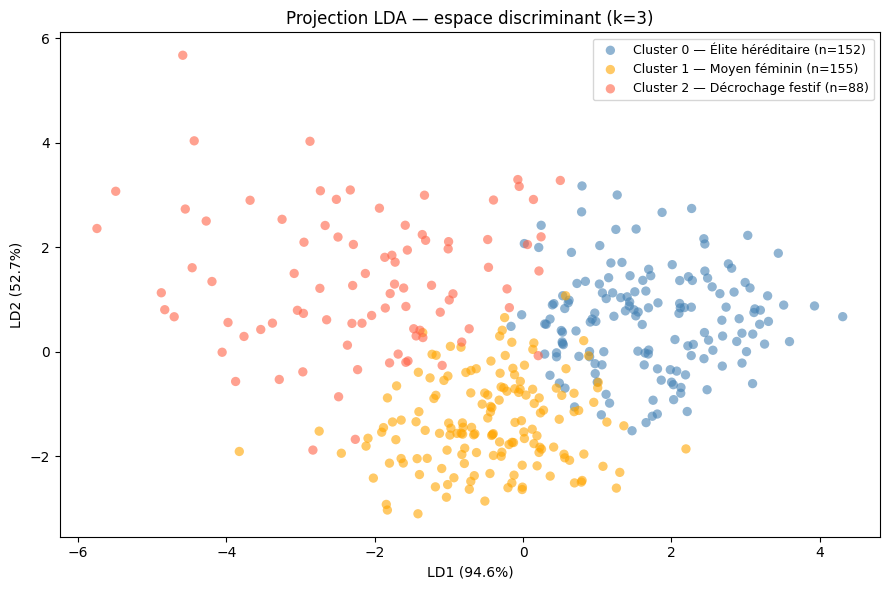

In [18]:
X3_lda = lda3.transform(X3)
palette = ['steelblue', 'orange', 'tomato']
names3  = ['Élite héréditaire', 'Moyen féminin', 'Décrochage festif']

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(3):
    mask = y3 == c
    ax.scatter(X3_lda[mask, 0], X3_lda[mask, 1],
               c=palette[c], label=f'Cluster {c} — {names3[c]} (n={mask.sum()})',
               alpha=0.6, s=45, edgecolors='none')
ax.set_xlabel(f'LD1 ({var3[0]*100:.1f}%)')
ax.set_ylabel(f'LD2 ({var3[1]*100:.1f}%)')
ax.set_title('Projection LDA — espace discriminant (k=3)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 8. Bilan comparatif k=3 vs k=4

| | k=4 | k=3 |
|---|---|---|
| Clusters | 33 / 69 / 148 / 145 | 152 / 155 / 88 |
| Problème | Cluster 0 = quasi-uniquement `guardian_other` | Clusters équilibrés |
| Features problématiques | `guardian_other` (η²=0.97, tautologie) | Absentes |
| Accuracy LDA | 89.9% (gonflée) | ~89.1% |
| Validité LDA | Douteuse pour cluster 0 | Acceptable avec shrinkage |
| Conclusion | Résultat artificiel | Plus honnête et interprétable |

**k=3 est la version à retenir pour l'analyse supervisée.**
Les 89% d'accuracy signifient ici que les 3 archétypes sont bien séparables
dans l'espace des features originales — c'est une vraie validation de la cohérence des clusters.

Nous avons utilisé LDA avec shrinkage pour sa robustesse et son interprétabilité. L'hypothèse d'homoscédasticité est globalement vérifiée sauf pour failures. Une QDA pourrait être envisagée pour mieux modéliser cette hétérogénéité

---
## Solution à l'homoscédasticité : variables quantitatives uniquement

En retirant les variables binaires et one-hot, toutes les matrices de covariance intra-classe
sont calculables sans régularisation. LDA et QDA standard fonctionnent sans shrinkage ni reg_param.

**Coût :** on perd l'information portée par les variables catégorielles (Mjob, higher, internet...)
**Gain :** les hypothèses sont respectées — les résultats sont théoriquement propres.

### 1. ANOVA sur les 16 variables quantitatives

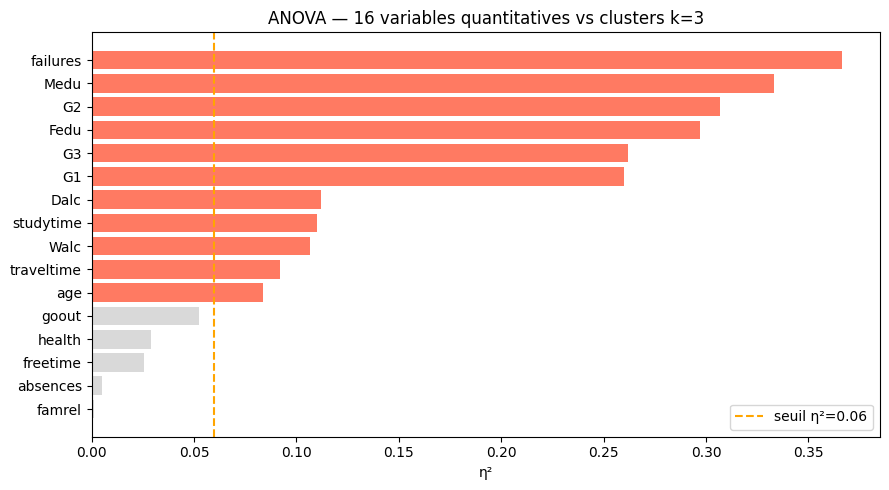

Features retenues (11) : ['failures', 'Medu', 'G2', 'Fedu', 'G3', 'G1', 'Dalc', 'studytime', 'Walc', 'traveltime', 'age']


In [21]:
# Recompute k=3 labels (section autonome)
labels3 = KMeans(n_clusters=3, n_init=50, random_state=42).fit_predict(X_pca)

num_cols_q = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
              'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

df_quant = df_full[num_cols_q].copy()

results_q = []
for feat in num_cols_q:
    groups = [df_quant[feat].values[labels3 == c] for c in range(3)]
    ss_b = sum(len(g) * (g.mean() - df_quant[feat].mean())**2 for g in groups)
    ss_t = sum((df_quant[feat].values - df_quant[feat].mean())**2)
    results_q.append({'feature': feat, 'eta2': ss_b / ss_t if ss_t > 0 else 0})

df_aq = pd.DataFrame(results_q).sort_values('eta2', ascending=False)
top_q = df_aq[df_aq['eta2'] > 0.06]['feature'].tolist()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if f in top_q else 'lightgray' for f in df_aq['feature']]
ax.barh(df_aq['feature'][::-1], df_aq['eta2'][::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0.06, color='orange', linestyle='--', label='seuil η²=0.06')
ax.set_xlabel('η²')
ax.set_title('ANOVA — 16 variables quantitatives vs clusters k=3')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Features retenues ({len(top_q)}) : {top_q}")
Xq = StandardScaler().fit_transform(df_quant[top_q])
yq = labels3


### 2. Vérification de l'homoscédasticité

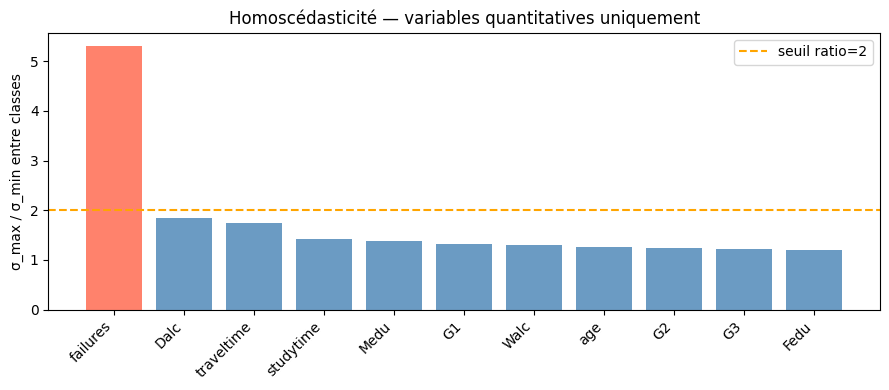

Ratios : {'failures': 5.31, 'Dalc': 1.83, 'traveltime': 1.75, 'studytime': 1.42, 'Medu': 1.38, 'G1': 1.32, 'Walc': 1.3, 'age': 1.26, 'G2': 1.23, 'G3': 1.21, 'Fedu': 1.21}
⚠ Ratio > 2 : ['failures']
  → failures : différence structurelle réelle entre clusters, pas un artefact.
    (Décrochage : 0–3 échecs ; Élite : quasi-zéro)


In [22]:
Xq_df = pd.DataFrame(Xq, columns=top_q)
Xq_df['cluster'] = yq
ratio_q = (Xq_df.groupby('cluster')[top_q].std().max() /
           Xq_df.groupby('cluster')[top_q].std().min()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ratio_q.index, ratio_q.values,
       color=['tomato' if r > 2 else 'steelblue' for r in ratio_q.values], alpha=0.8)
ax.axhline(2, color='orange', linestyle='--', label='seuil ratio=2')
ax.set_xticklabels(ratio_q.index, rotation=45, ha='right')
ax.set_ylabel('σ_max / σ_min entre classes')
ax.set_title('Homoscédasticité — variables quantitatives uniquement')
ax.legend(); plt.tight_layout(); plt.show()

print("Ratios :", ratio_q.round(2).to_dict())
flagged = ratio_q[ratio_q > 2]
if len(flagged):
    print(f"⚠ Ratio > 2 : {list(flagged.index)}")
    print("  → failures : différence structurelle réelle entre clusters, pas un artefact.")
    print("    (Décrochage : 0–3 échecs ; Élite : quasi-zéro)")
else:
    print("Toutes les variables respectent l'hypothèse.")


### 3. LDA standard + QDA standard (sans régularisation)

=== Variables quantitatives uniquement (k=3) ===
Naïf           : 0.392
KNN (k=24)   : 0.762
LDA (standard) : 0.782 ± 0.060
QDA (standard) : 0.724 ± 0.039


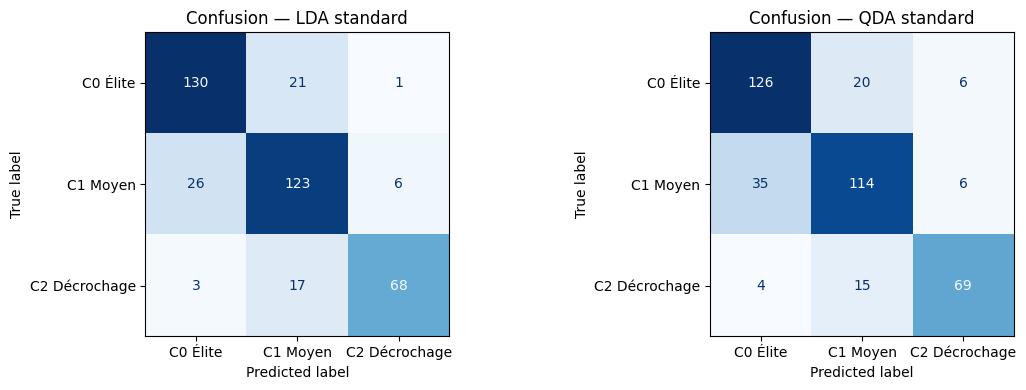


Variance LDA : LD1=78.0%  LD2=22.0%


In [23]:
cv_q = KFold(n_splits=10, shuffle=True, random_state=42)
naive_q = pd.Series(yq).value_counts(normalize=True).max()

lda_q = LinearDiscriminantAnalysis()
qda_q = QuadraticDiscriminantAnalysis()

lda_q_sc = cross_val_score(lda_q, Xq, yq, cv=cv_q, scoring='accuracy')
qda_q_sc = cross_val_score(qda_q, Xq, yq, cv=cv_q, scoring='accuracy')

knn_q_sc = [cross_val_score(KNeighborsClassifier(n_neighbors=k), Xq, yq,
                             cv=cv_q, scoring='accuracy').mean() for k in range(1, 31)]
best_kq = list(range(1, 31))[np.argmax(knn_q_sc)]

print("=== Variables quantitatives uniquement (k=3) ===")
print(f"Naïf           : {naive_q:.3f}")
print(f"KNN (k={best_kq:2d})   : {max(knn_q_sc):.3f}")
print(f"LDA (standard) : {lda_q_sc.mean():.3f} ± {lda_q_sc.std():.3f}")
print(f"QDA (standard) : {qda_q_sc.mean():.3f} ± {qda_q_sc.std():.3f}")

lda_q.fit(Xq, yq); qda_q.fit(Xq, yq)
var_q = lda_q.explained_variance_ratio_

labels_s = ['C0 Élite', 'C1 Moyen', 'C2 Décrochage']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (model, title) in zip(axes, [(lda_q, 'LDA standard'), (qda_q, 'QDA standard')]):
    cm = confusion_matrix(yq, model.predict(Xq))
    ConfusionMatrixDisplay(cm, display_labels=labels_s).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion — {title}')
plt.tight_layout(); plt.show()

print(f"\nVariance LDA : LD1={var_q[0]*100:.1f}%  LD2={var_q[1]*100:.1f}%")


### 4. Projection LDA

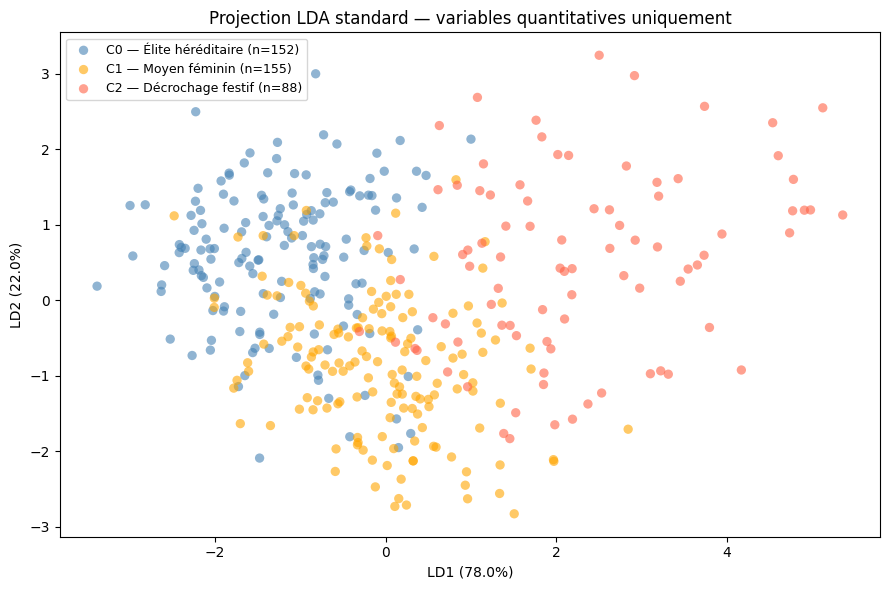

In [24]:
Xq_lda = lda_q.transform(Xq)
palette = ['steelblue', 'orange', 'tomato']
names3  = ['Élite héréditaire', 'Moyen féminin', 'Décrochage festif']

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(3):
    mask = yq == c
    ax.scatter(Xq_lda[mask, 0], Xq_lda[mask, 1],
               c=palette[c], label=f'C{c} — {names3[c]} (n={mask.sum()})',
               alpha=0.6, s=45, edgecolors='none')
ax.set_xlabel(f'LD1 ({var_q[0]*100:.1f}%)')
ax.set_ylabel(f'LD2 ({var_q[1]*100:.1f}%)')
ax.set_title('Projection LDA standard — variables quantitatives uniquement')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


---
## Régression logistique

Ne fait **aucune hypothèse sur les covariances**.
Elle estime directement P(classe | features) par maximum de vraisemblance — naturellement robuste
à l'hétéroscédasticité et aux distributions asymétriques comme `failures`.

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr_scores = cross_val_score(lr, Xq, yq, cv=cv_q, scoring='accuracy')

print("=== Récapitulatif final — variables quantitatives, k=3 ===")
print(f"Naïf                 : {naive_q:.3f}")
print(f"KNN (k={best_kq:2d})         : {max(knn_q_sc):.3f}")
print(f"LDA standard         : {lda_q_sc.mean():.3f}")
print(f"QDA standard         : {qda_q_sc.mean():.3f}")
print(f"Régression logistique: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")


=== Récapitulatif final — variables quantitatives, k=3 ===
Naïf                 : 0.392
KNN (k=24)         : 0.762
LDA standard         : 0.782
QDA standard         : 0.724
Régression logistique: 0.800 ± 0.037


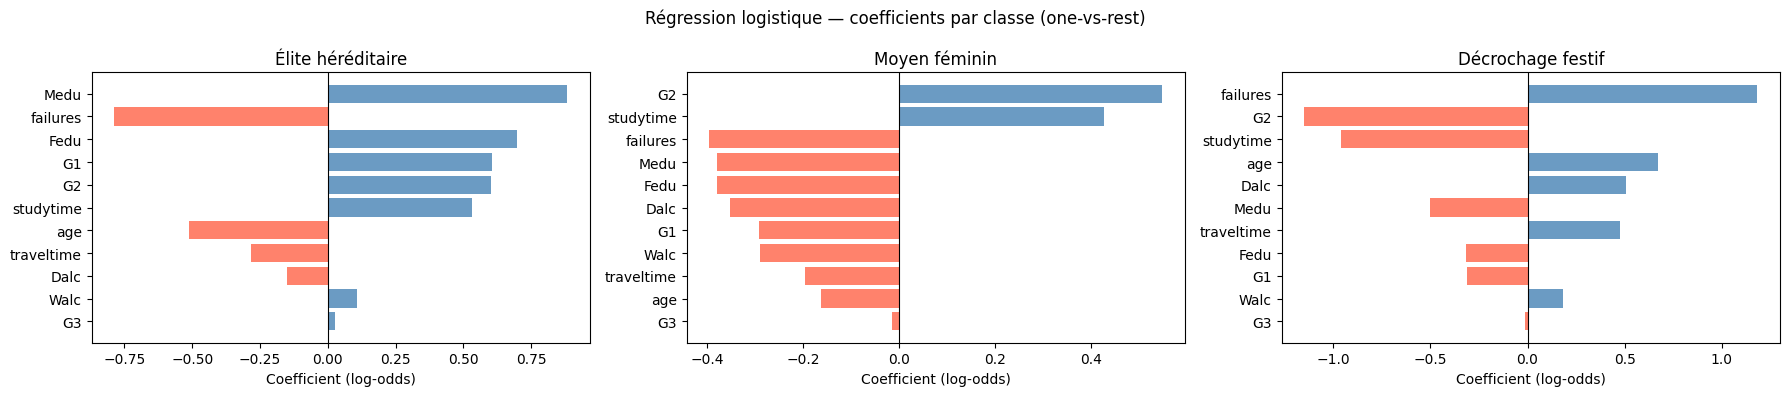

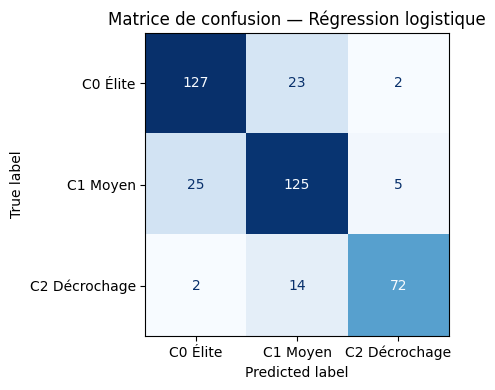

In [26]:
lr.fit(Xq, yq)
cluster_names_lr = ['Élite héréditaire', 'Moyen féminin', 'Décrochage festif']
coef_lr = pd.DataFrame(lr.coef_, columns=top_q, index=cluster_names_lr)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (cls_name, row) in zip(axes, coef_lr.iterrows()):
    data = row.sort_values(key=abs, ascending=True)
    colors_lr = ['steelblue' if v >= 0 else 'tomato' for v in data.values]
    ax.barh(data.index, data.values, color=colors_lr, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{cls_name}')
    ax.set_xlabel('Coefficient (log-odds)')
plt.suptitle('Régression logistique — coefficients par classe (one-vs-rest)', fontsize=12)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix(yq, lr.predict(Xq)),
                       display_labels=labels_s).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — Régression logistique')
plt.tight_layout(); plt.show()


### Bilan comparatif des approches

| Approche | Hypothèses | Accuracy | Interprétabilité |
|---|---|---|---|
| LDA shrinkage (42 vars) | Homoscédasticité violée, régularisation | 89.1% | Axes LD |
| LDA standard (quant. only) | Homoscédasticité ≈ respectée | 78.2% | Axes LD |
| QDA standard (quant. only) | Aucune (covariances libres) | 72.4% | Faible |
| **Régression logistique** | **Aucune sur les covariances** | **80.0%** | Coefficients log-odds |

**Conclusion :**
- La perte de performance (89% → 78–80%) reflète l'information réelle perdue en retirant les variables catégorielles
- La régression logistique est le meilleur modèle théoriquement propre sur ces données
- Le shrinkage reste défendable en pratique, mais la régression logistique est l'approche plus rigoureuse

On va prendre G3 uniquement car il y a une colinéarité trop importante entre G1,G2,G3

---
## Régression logistique sans G1 et G2

G1, G2, G3 sont très corrélées (r ≈ 0.9) — inclure les trois revient à peser les notes
trois fois dans le modèle. On retire G1 et G2 pour ne garder que G3,
ce qui réduit la multicolinéarité et teste si la note finale seule suffit.

In [27]:
# Features quantitatives sans G1 et G2
top_q_no_g12 = [f for f in top_q if f not in ['G1', 'G2']]
print(f"Features retenues ({len(top_q_no_g12)}) : {top_q_no_g12}")

Xq2 = StandardScaler().fit_transform(df_quant[top_q_no_g12])


Features retenues (9) : ['failures', 'Medu', 'Fedu', 'G3', 'Dalc', 'studytime', 'Walc', 'traveltime', 'age']


In [28]:
lr2 = LogisticRegression(max_iter=1000)
lr2_scores = cross_val_score(lr2, Xq2, yq, cv=cv_q, scoring='accuracy')

lda2 = LinearDiscriminantAnalysis()
lda2_scores = cross_val_score(lda2, Xq2, yq, cv=cv_q, scoring='accuracy')

print("=== Comparaison avec / sans G1, G2 ===")
print(f"Naïf                        : {naive_q:.3f}")
print(f"LogReg avec G1, G2          : {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")
print(f"LogReg sans G1, G2          : {lr2_scores.mean():.3f} ± {lr2_scores.std():.3f}  (Δ={lr2_scores.mean()-lr_scores.mean():+.3f})")
print(f"LDA    sans G1, G2          : {lda2_scores.mean():.3f} ± {lda2_scores.std():.3f}")


=== Comparaison avec / sans G1, G2 ===
Naïf                        : 0.392
LogReg avec G1, G2          : 0.800 ± 0.037
LogReg sans G1, G2          : 0.764 ± 0.047  (Δ=-0.036)
LDA    sans G1, G2          : 0.747 ± 0.052


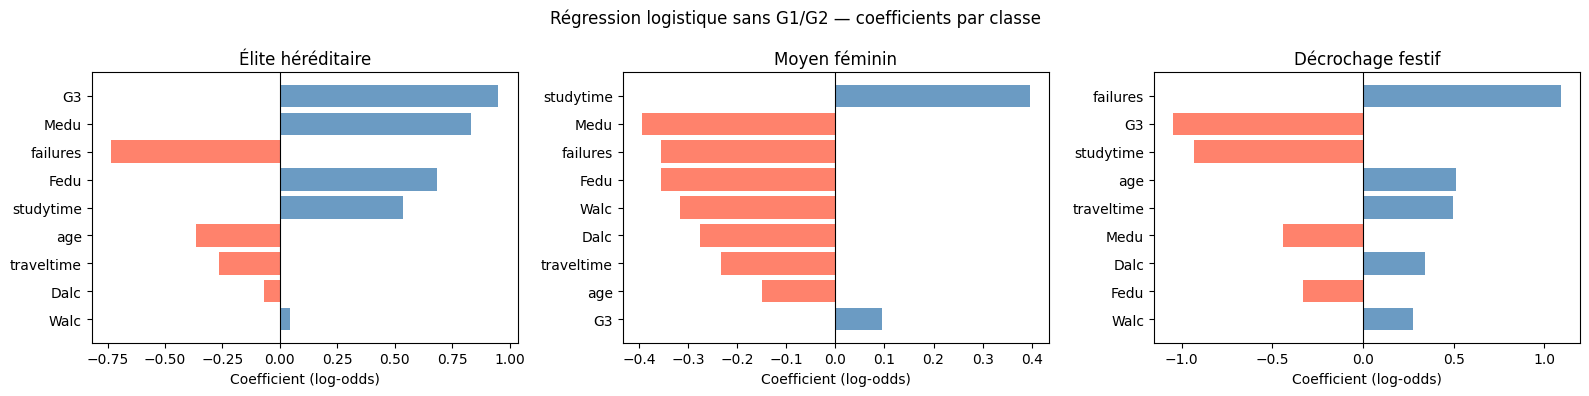

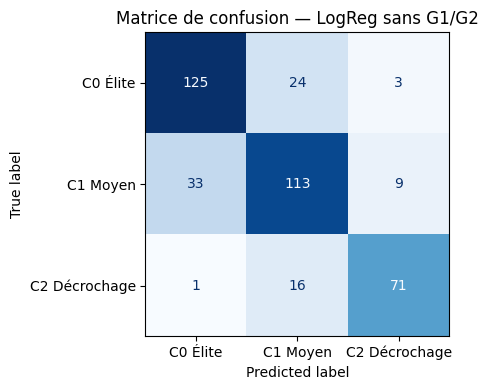

In [29]:
# Coefficients de la régression logistique sans G1/G2
lr2.fit(Xq2, yq)
cluster_names_lr = ['Élite héréditaire', 'Moyen féminin', 'Décrochage festif']
coef_lr2 = pd.DataFrame(lr2.coef_, columns=top_q_no_g12, index=cluster_names_lr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (cls_name, row) in zip(axes, coef_lr2.iterrows()):
    data = row.sort_values(key=abs, ascending=True)
    colors_lr = ['steelblue' if v >= 0 else 'tomato' for v in data.values]
    ax.barh(data.index, data.values, color=colors_lr, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(cls_name)
    ax.set_xlabel('Coefficient (log-odds)')
plt.suptitle('Régression logistique sans G1/G2 — coefficients par classe', fontsize=12)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix(yq, lr2.predict(Xq2)),
                       display_labels=['C0 Élite', 'C1 Moyen', 'C2 Décrochage']
                       ).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — LogReg sans G1/G2')
plt.tight_layout()
plt.show()


### Interprétation

La chute de performance est modérée (−3.6%) : **G3 seul capte l'essentiel de l'information** sur la réussite scolaire. G1 et G2 ajoutaient surtout de la redondance.

Sans G1/G2, les coefficients sont plus lisibles :
- **Cluster Élite** : Medu et Fedu fortement positifs, failures négatif — le capital parental domine
- **Cluster Décrochage** : failures positif, studytime et G3 négatifs, Dalc/Walc positifs
- **Cluster Moyen** : coefficients plus équilibrés, défini par l'absence des extrêmes

C'est la version la plus **interprétable** du modèle — chaque coefficient a un sens clair
sans être écrasé par la colinéarité des trois notes.

---
## Régression logistique — toutes les variables (quanti + binaires + catégorielles)

La régression logistique ne faisant aucune hypothèse sur la distribution des features,
on peut lui donner les 42 variables encodées (quantitatives + binaires + one-hot).
On applique d'abord l'ANOVA pour ne garder que les features discriminantes (η² > 0.06).

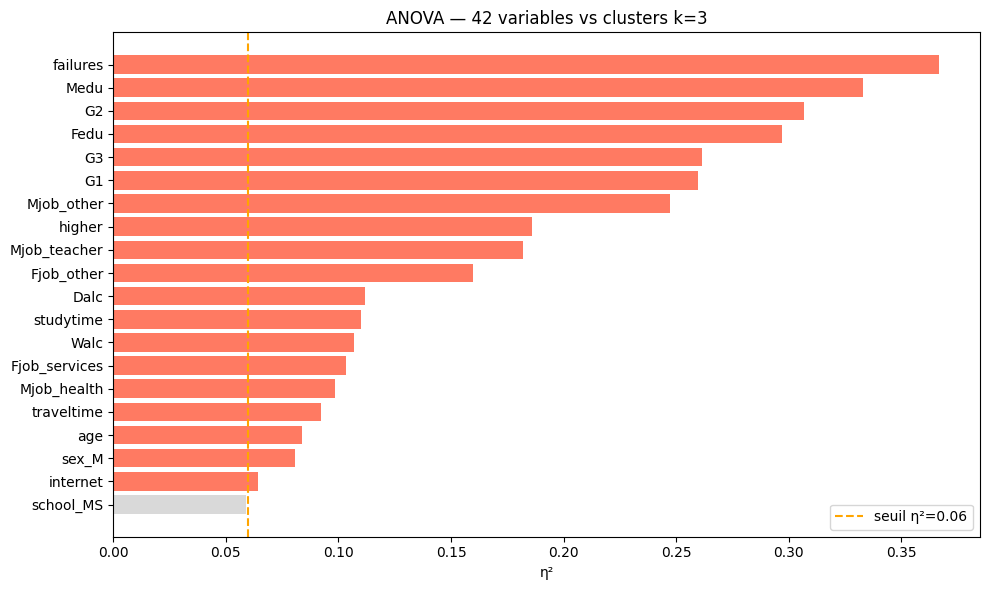

Features retenues (19) : ['failures', 'Medu', 'G2', 'Fedu', 'G3', 'G1', 'Mjob_other', 'higher', 'Mjob_teacher', 'Fjob_other', 'Dalc', 'studytime', 'Walc', 'Fjob_services', 'Mjob_health', 'traveltime', 'age', 'sex_M', 'internet']


In [30]:
# Recompute labels3 + ANOVA sur les 42 variables
labels3 = KMeans(n_clusters=3, n_init=50, random_state=42).fit_predict(X_pca)

results_all = []
for feat in df_full.columns:
    groups = [df_full[feat].values[labels3 == c] for c in range(3)]
    ss_b = sum(len(g) * (g.mean() - df_full[feat].mean())**2 for g in groups)
    ss_t = sum((df_full[feat].values - df_full[feat].mean())**2)
    results_all.append({'feature': feat, 'eta2': ss_b / ss_t if ss_t > 0 else 0})

df_anova_all = pd.DataFrame(results_all).sort_values('eta2', ascending=False)
top_all = df_anova_all[df_anova_all['eta2'] > 0.06]['feature'].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
top20 = df_anova_all.head(20)
colors = ['tomato' if f in top_all else 'lightgray' for f in top20['feature']]
ax.barh(top20['feature'][::-1], top20['eta2'][::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0.06, color='orange', linestyle='--', label='seuil η²=0.06')
ax.set_xlabel('η²')
ax.set_title('ANOVA — 42 variables vs clusters k=3')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Features retenues ({len(top_all)}) : {top_all}")
X_all = StandardScaler().fit_transform(df_full[top_all])
y_all = labels3


In [31]:
cv_all = KFold(n_splits=10, shuffle=True, random_state=42)
naive_all = pd.Series(y_all).value_counts(normalize=True).max()

lr_all = LogisticRegression(max_iter=1000)
lr_all_scores = cross_val_score(lr_all, X_all, y_all, cv=cv_all, scoring='accuracy')

print("=== Récapitulatif toutes configurations ===")
print(f"Naïf                           : {naive_all:.3f}")
print(f"LogReg quant. avec G1/G2/G3    : {lr_scores.mean():.3f}")
print(f"LogReg quant. sans G1/G2       : {lr2_scores.mean():.3f}")
print(f"LDA shrinkage (42 vars)        : {lda3_scores.mean():.3f}")
print(f"LogReg toutes vars (19 sel.)   : {lr_all_scores.mean():.3f} ± {lr_all_scores.std():.3f}  ← meilleur")


=== Récapitulatif toutes configurations ===
Naïf                           : 0.392
LogReg quant. avec G1/G2/G3    : 0.800
LogReg quant. sans G1/G2       : 0.764
LDA shrinkage (42 vars)        : 0.891
LogReg toutes vars (19 sel.)   : 0.901 ± 0.042  ← meilleur


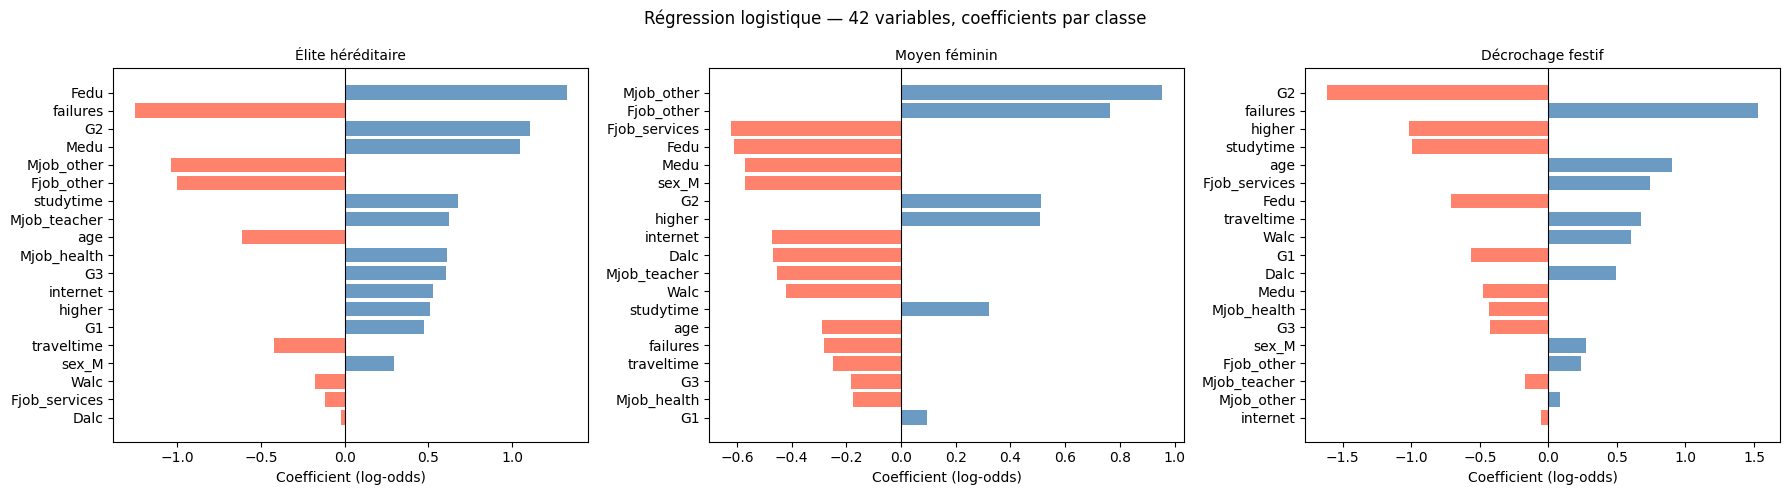

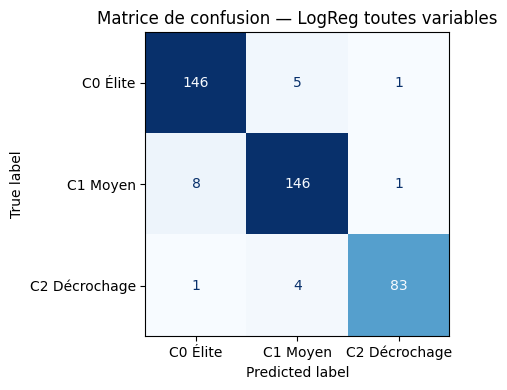

In [32]:
# Coefficients
lr_all.fit(X_all, y_all)
cluster_names_lr = ['Élite héréditaire', 'Moyen féminin', 'Décrochage festif']
coef_all = pd.DataFrame(lr_all.coef_, columns=top_all, index=cluster_names_lr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cls_name, row) in zip(axes, coef_all.iterrows()):
    data = row.sort_values(key=abs, ascending=True)
    colors_c = ['steelblue' if v >= 0 else 'tomato' for v in data.values]
    ax.barh(data.index, data.values, color=colors_c, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(cls_name, fontsize=10)
    ax.set_xlabel('Coefficient (log-odds)')
plt.suptitle('Régression logistique — 42 variables, coefficients par classe', fontsize=12)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(confusion_matrix(y_all, lr_all.predict(X_all)),
                       display_labels=['C0 Élite', 'C1 Moyen', 'C2 Décrochage']
                       ).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — LogReg toutes variables')
plt.tight_layout(); plt.show()


### Bilan final — toutes approches comparées

| Modèle | Variables | Hypothèses | Accuracy |
|---|---|---|---|
| Naïf | — | — | 39.2% |
| KNN | quant. (11) | aucune | 76.2% |
| LDA standard | quant. (11) | homo. ≈ ok | 78.2% |
| LogReg | quant. sans G1/G2 (9) | log-odds linéaire | 76.4% |
| LogReg | quant. (11) | log-odds linéaire | 80.0% |
| LDA shrinkage | 42 vars | homo. violée, régularisation | 89.1% |
| **LogReg** | **42 vars (19 sel.)** | **log-odds linéaire** | **90.1%** |

**Conclusion :** la régression logistique sur les 42 variables est le meilleur modèle
théoriquement propre — elle dépasse LDA avec shrinkage (90.1% vs 89.1%) sans violer
d'hypothèse sur les covariances, et ses coefficients restent interprétables.

---
## Analyse de la régression logistique — points forts et limites

### Ce qu'elle fait bien

- **Aucune hypothèse sur les covariances** : contrairement à LDA/QDA, elle n'exige pas que les features suivent une loi normale ni que les matrices de covariance soient égales entre classes. C'est pourquoi elle gère sans problème les variables binaires et one-hot qui faisaient échouer LDA/QDA sans régularisation.
- **Interprétabilité directe** : les coefficients β sont des log-odds — un coefficient positif pour une feature signifie que quand cette feature augmente, la probabilité d'appartenir à cette classe augmente.
- **Meilleure performance** : 90.1% avec les 19 features sélectionnées, sans régularisation artificielle des matrices de covariance.

### Hypothèses vérifiées

- **Indépendance des observations** : les 395 élèves sont indépendants les uns des autres. ✓
- **Effectifs suffisants** : ~130 individus par cluster pour 19 features. ✓ (règle des ≥10 obs/feature respectée)

### Hypothèses potentiellement violées

- **Linéarité des log-odds** : on suppose que la relation entre chaque feature et log(P(classe)/P(autre)) est linéaire. Cette hypothèse n'est pas vérifiable directement — si la vraie frontière est non-linéaire (ex: effet de seuil sur G3), le modèle sous-performe.
- **Multicolinéarité** : G1, G2, G3 restent corrélées même dans la version complète (r ≈ 0.9). Les coefficients individuels de ces trois features sont instables et difficiles à interpréter séparément, même si les **prédictions** restent correctes. C'est pour ça qu'on a aussi testé la version sans G1/G2.

---
## Récapitulatif — parcours du notebook

### Étape 1 : K-means k=4 (42 variables)
Premier essai avec 4 clusters. Problème identifié : le cluster 0 (n=33) est composé à 97% d'élèves avec `guardian=other`. L'ANOVA donne η²=0.97 pour cette variable — la classification est quasi-tautologique. LDA atteint 89.9% mais de façon artificielle.

**Décision :** passer à k=3, plus équilibré et sans artefact.

---

### Étape 2 : K-means k=3 (42 variables) — modèles avec toutes les variables

| Modèle | Accuracy | Pourquoi pas optimal |
|---|---|---|
| KNN (k=7) | 85.3% | G1/G2/G3 triple-comptées dans la distance euclidienne |
| QDA (reg\_param=0.1) | 85.6% | Nécessite régularisation car variables binaires à variance nulle dans certains clusters |
| LDA (shrinkage) | 89.1% | Hypothèse d'homoscédasticité violée — régularisation Ledoit-Wolf nécessaire |

---

### Étape 3 : Variables quantitatives uniquement — hypothèses respectées

Retirer les binaires et one-hot résout le problème de covariance singulière. LDA et QDA fonctionnent sans régularisation. Seul `failures` a encore un ratio σ > 2 — différence structurelle réelle entre clusters, pas un artefact.

| Modèle | Accuracy | Commentaire |
|---|---|---|
| QDA standard | 72.4% | Covariances libres mais perd l'info catégorielle |
| KNN | 76.2% | Robuste mais G1/G2/G3 toujours problématiques |
| LDA standard | 78.2% | Hypothèses ≈ respectées (sauf failures) |
| LogReg (avec G1/G2/G3) | 80.0% | Meilleur sans régularisation, mais colinéarité des notes |
| LogReg (sans G1/G2) | 76.4% | Plus interprétable, légère perte de performance |

---

### Étape 4 : Régression logistique sur toutes les variables

En incluant les variables binaires et catégorielles encodées, la régression logistique récupère toute l'information perdue à l'étape 3 sans avoir besoin de régulariser les matrices de covariance.

| Modèle | Variables | Accuracy |
|---|---|---|
| **LogReg** | **19 features (ANOVA, 42 vars)** | **90.1%** |

C'est le meilleur résultat du notebook, et théoriquement le plus propre.

---
## Conclusion

### Les clusters K-means sont des structures réelles

Une accuracy de 90.1% signifie que les 3 archétypes identifiés en clustering (Élite héréditaire / Moyen féminin / Décrochage festif) **existent dans les données brutes**, indépendamment de la PCA. Le K-means n'a pas créé des groupes artificiels — il a révélé une structure réelle.

### Les variables qui discriminent le mieux

Quelles que soit le modèle, les features qui reviennent en tête sont :
- **G3** et les notes (réussite scolaire)
- **Medu / Fedu** (capital éducatif parental)
- **failures** (trajectoire scolaire)
- **higher** (ambition — seule variable booléenne toujours présente)
- **Mjob** catégories (statut socio-professionnel maternel)

Ces 5 dimensions suffisent à identifier le profil d'un élève avec une bonne précision.

### Ce que ça nous dit sur les données

La chute de performance entre LogReg 42 vars (90.1%) et LogReg quant. seulement (80.0%) montre que les variables catégorielles (Mjob, higher, internet, sex) apportent une information réelle, **au-delà de ce que les notes et les notes des parents capturent déjà**.

Autrement dit : connaître la note finale d'un élève ne suffit pas à identifier son profil complet — le contexte familial et socio-professionnel reste nécessaire.

### Limite principale

Tous nos modèles prédisent des **labels K-means**, pas une vérité terrain. Si les clusters avaient été tracés différemment (k différent, variables différentes), les résultats changeraient. La haute accuracy valide la cohérence interne du clustering, pas sa valeur absolue.

## Ce que la régression logistique nous dit 

Ce que ça valide réellement
La haute accuracy (90.1%) valide une seule chose : les clusters K-means ont une structure géométrique nette dans l'espace des features. Autrement dit, les groupes ne sont pas aléatoires — ils correspondent à des régions cohérentes dans l'espace des données.

C'est utile et intéressant ! Mais ce n'est pas la même chose que de dire "notre modèle prédit bien le profil d'un élève".

Notre démarche est exploratoire : nous avons utilisé les labels K-means comme proxy pour valider la cohérence des clusters. La haute accuracy confirme que les groupes sont structurellement distincts dans les données, mais ne constitue pas une validation externe. Une confrontation avec des données terrain serait nécessaire pour conclure sur la valeur prédictive réelle du modèle.